# **Library**

In [5]:
import os
import numpy as np
import cv2
from skimage import exposure
from glob import glob
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, TensorBoard
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import CustomObjectScope
from sklearn.metrics import f1_score, jaccard_score, precision_score, recall_score
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPool2D, Conv2DTranspose, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras import layers, models

In [6]:
base_dir = r"/kaggle/input/brain-tumor-segmentation"
print(os.listdir(base_dir))

['images', 'masks']


In [7]:
print("Images:", len(os.listdir(base_dir + "/images")))
print("Masks :", len(os.listdir(base_dir + "/masks")))

Images: 3064
Masks : 3064


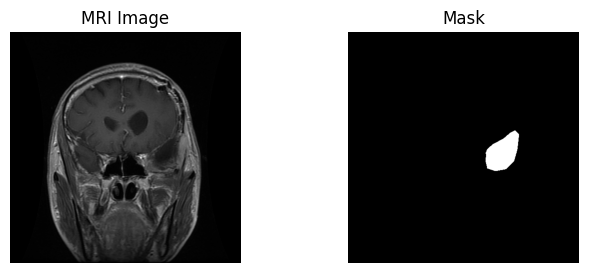

In [8]:
img_name = os.listdir(base_dir + "/images")[0]

img_path  = base_dir + "/images/" + img_name
mask_path = base_dir + "/masks/" + img_name

image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(8,3))

plt.subplot(1,2,1)
plt.title("MRI Image")
plt.imshow(image, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask, cmap='gray')
plt.axis("off")

plt.show()


In [9]:
print("Image shape:", image.shape)
print("Mask unique values:", set(mask.flatten()))


Image shape: (512, 512)
Mask unique values: {0, 255}


In [10]:
def load_data(base_dir, target_size=(128, 128)):
    images = []
    masks = []

    images_dir = os.path.join(base_dir, "images")
    masks_dir = os.path.join(base_dir, "masks")

    if not os.path.exists(images_dir):
        raise FileNotFoundError(f"Images folder not found: {images_dir}")
    if not os.path.exists(masks_dir):
        raise FileNotFoundError(f"Masks folder not found: {masks_dir}")

    # Get list of files
    image_files = sorted(os.listdir(images_dir))
    mask_files = sorted(os.listdir(masks_dir))

    
    if len(image_files) != len(mask_files):
        print(f"Warning: Number of files don't match. Images: {len(image_files)}, Masks: {len(mask_files)}")

    for img_name in image_files:

        img_path = os.path.join(images_dir, img_name)

        mask_path = os.path.join(masks_dir, img_name)

        if not os.path.exists(mask_path):
            print(f"Warning: Mask not found for image {img_name}")
            continue

        try:
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if image is None:
                print(f"Warning: Could not load image {img_path}")
                continue

            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is None:
                print(f"Warning: Could not load mask {mask_path}")
                continue

            image = cv2.resize(image, target_size)
            mask = cv2.resize(mask, target_size)

            # Normalize values
            image = image / 255.0
            mask = mask / 255.0

            # Convert mask to binary
            mask = (mask > 0.5).astype(np.float32)

            # Reshape 
            image = np.expand_dims(image, axis=-1)  #(128, 128, 1)
            mask = np.expand_dims(mask, axis=-1)    # (128, 128, 1)

            images.append(image)
            masks.append(mask)

        except Exception as e:
            print(f"Error processing {img_name}: {e}")
            continue

    # Convert to numpy arrays
    images = np.array(images, dtype=np.float32)
    masks = np.array(masks, dtype=np.float32)

    print(f"Loaded {len(images)} images and {len(masks)} masks")
    print(f"Images shape: {images.shape}")
    print(f"Masks shape: {masks.shape}")

    return images, masks

In [ ]:
images = load_data(base_dir)

In [ ]:
masks = load_data(base_dir)

In [11]:
def visualize_samples(images, masks, num_samples=5):
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 3*num_samples))

    for i in range(num_samples):
        
        axes[i, 0].imshow(images[i].squeeze(), cmap='gray')
        axes[i, 0].set_title(f'MRI Image {i+1}')
        axes[i, 0].axis('off')

       
        axes[i, 1].imshow(masks[i].squeeze(), cmap='gray')
        axes[i, 1].set_title(f'Mask {i+1}')
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

visualize_samples(images, masks, num_samples=3)

Loaded 3064 images and 3064 masks
Images shape: (3064, 128, 128, 1)
Masks shape: (3064, 128, 128, 1)


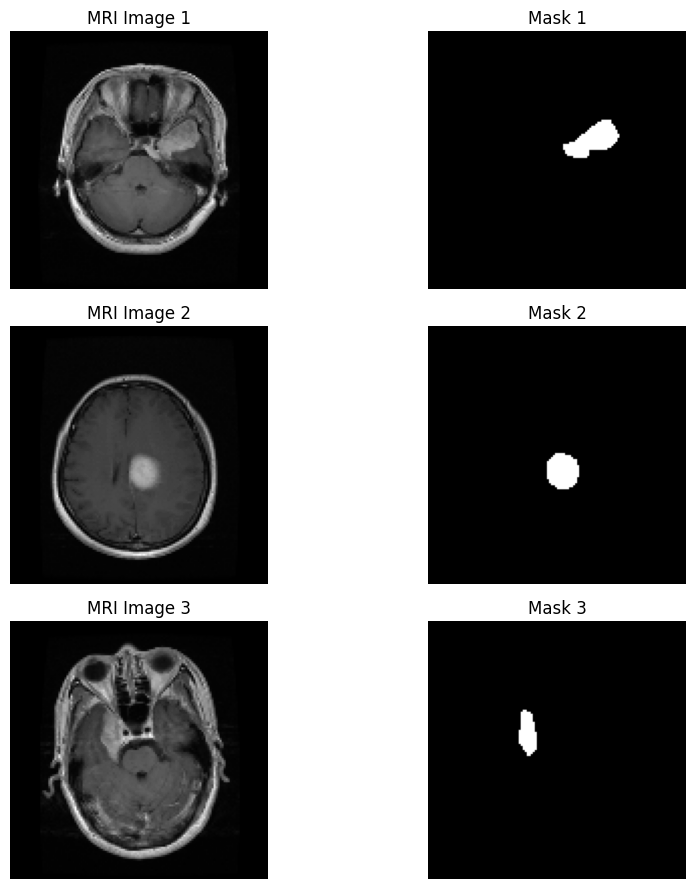

Total pixels: 50200576
Tumor pixels: 861464 (1.72%)
Non-tumor pixels: 49339112 (98.28%)


0.017160440549526763

In [12]:
def check_data_balance(masks):
    #flatten all masks
    all_pixels = masks.flatten()

    #count tumor,non-tumor pixels
    tumor_pixels = np.sum(all_pixels > 0.5)
    total_pixels = len(all_pixels)

    tumor_ratio = tumor_pixels / total_pixels
    non_tumor_ratio = 1 - tumor_ratio

    print(f"Total pixels: {total_pixels}")
    print(f"Tumor pixels: {tumor_pixels} ({tumor_ratio:.2%})")
    print(f"Non-tumor pixels: {total_pixels - tumor_pixels} ({non_tumor_ratio:.2%})")

    return tumor_ratio
    
check_data_balance(masks)

 # **Preprocessing**

# **ENHANCEMENT METHODS**

In [13]:
def apply_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    #convert uint8 for OpenCV
    image_uint8 = (image * 255).astype(np.uint8)

    # Create
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    # Apply
    enhanced = clahe.apply(image_uint8)

    # Convert to float32 [0, 1]
    return enhanced.astype(np.float32) / 255.0

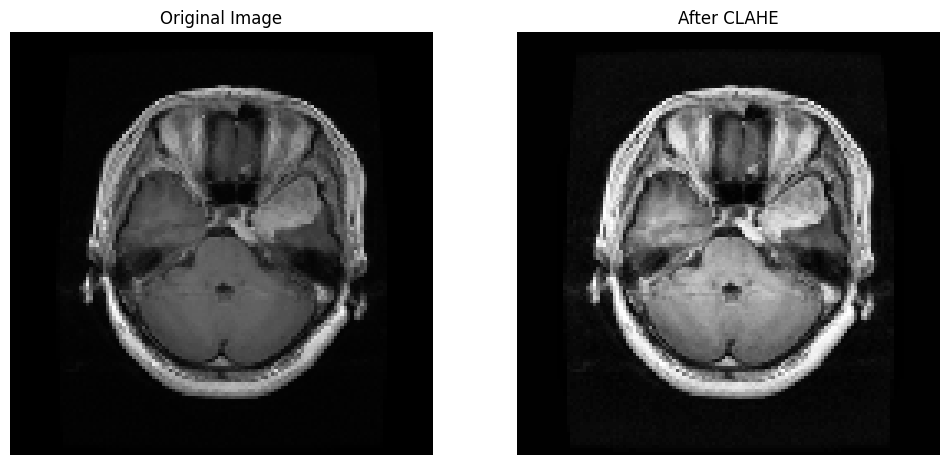

In [14]:
image = images[0]
clahe_result = apply_clahe(image)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(clahe_result, cmap='gray')
axes[1].set_title("After CLAHE")
axes[1].axis('off')

plt.show()

# gamma

In [15]:
def apply_gamma_correction(image, gamma=1.0):

        #lookup table
        inv_gamma = 1.0 / gamma
        table = np.array([((i / 255.0) ** inv_gamma) * 255
                         for i in np.arange(0, 256)]).astype("uint8")

        # Apply 
        image_uint8 = (image * 255).astype(np.uint8)
        corrected = cv2.LUT(image_uint8, table)

        return corrected.astype(np.float32) / 255.0

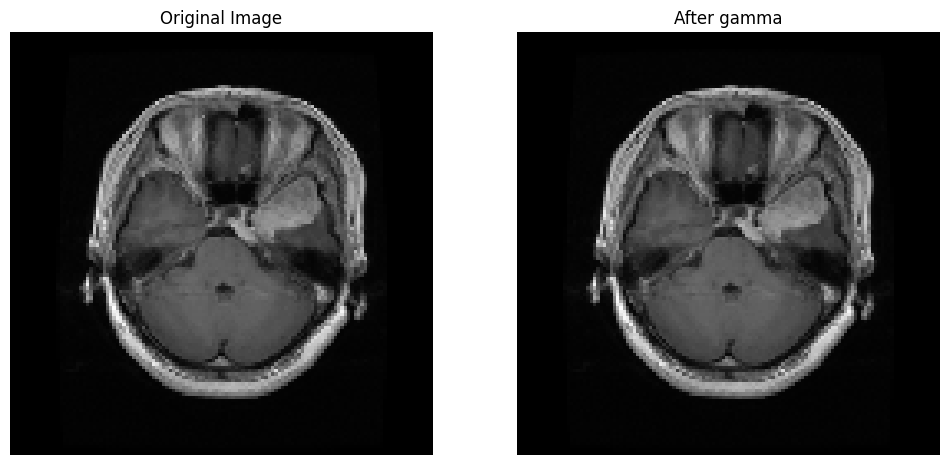

In [16]:
image = images[0]
gamma_result = apply_gamma_correction(image)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(gamma_result, cmap='gray')
axes[1].set_title("After gamma")
axes[1].axis('off')

plt.show()

In [17]:
def denoise_image(image, method='bilateral'):
        image_uint8 = (image * 255).astype(np.uint8)

        if method == 'bilateral':
            # Bilateral filter preserves edges
            denoised = cv2.bilateralFilter(image_uint8, d=9,
                                          sigmaColor=75, sigmaSpace=75)

        elif method == 'nlm':
            denoised = cv2.fastNlMeansDenoising(image_uint8, h=10)

        elif method == 'gaussian':
            # Gaussian blur
            denoised = cv2.GaussianBlur(image_uint8, (5, 5), 0)

        else:
            denoised = image_uint8

        return denoised.astype(np.float32) / 255.0

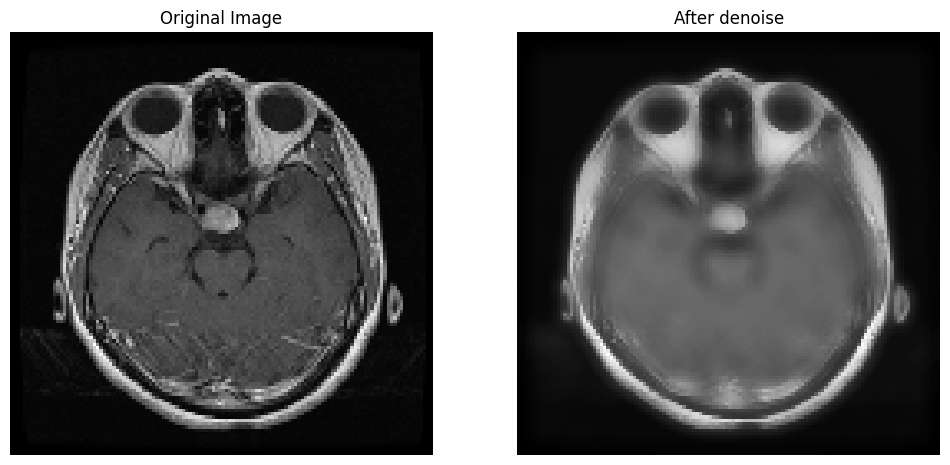

In [18]:
image = images[5]
denoise_result  = denoise_image(image)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# befor
axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

# after
axes[1].imshow(denoise_result, cmap='gray')
axes[1].set_title("After denoise")
axes[1].axis('off')

plt.show()

In [19]:
def enhance_edges_laplacian(image):
    #Ensure image is 2D
    image_2d = image.squeeze()

    laplacian = cv2.Laplacian(image_2d, cv2.CV_32F)

    #absolute value and normalize
    laplacian = np.abs(laplacian)
    laplacian = cv2.normalize(laplacian, None, 0, 1, cv2.NORM_MINMAX)

    #sharpen by Laplacian
    sharpened = cv2.addWeighted(image_2d, 1.5, laplacian, -0.5, 0)

    return np.clip(sharpened, 0, 1)

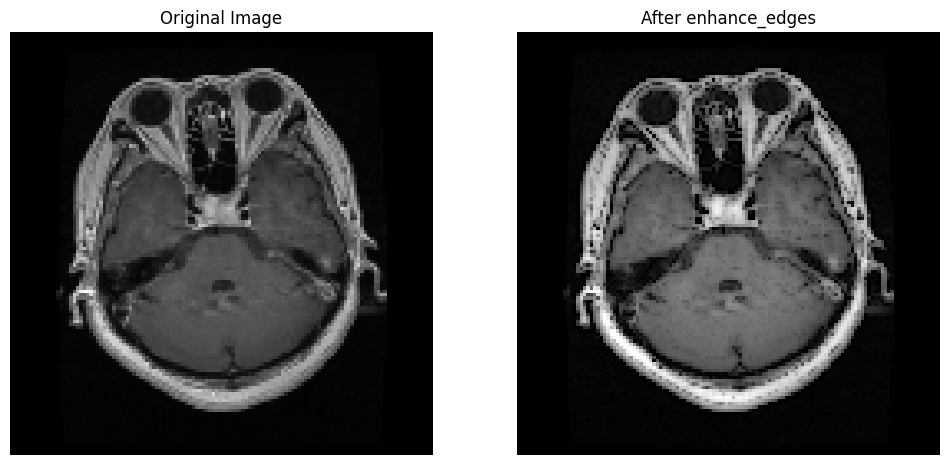

In [20]:
image = images[6]
enhance_edges_result = enhance_edges_laplacian(image)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(enhance_edges_result, cmap='gray')
axes[1].set_title("After enhance_edges")
axes[1].axis('off')

plt.show()

# MORPHOLOGICAL OPERATIONS

In [21]:
def morphological_opening(image, kernel_size=3):
    image_uint8 = (image * 255).astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    opened = cv2.morphologyEx(image_uint8, cv2.MORPH_OPEN, kernel)
    return opened.astype(np.float32) / 255.0

In [22]:
def morphological_closing(image, kernel_size=3):
    image_uint8 = (image * 255).astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    closed = cv2.morphologyEx(image_uint8, cv2.MORPH_CLOSE, kernel)
    return closed.astype(np.float32) / 255.0

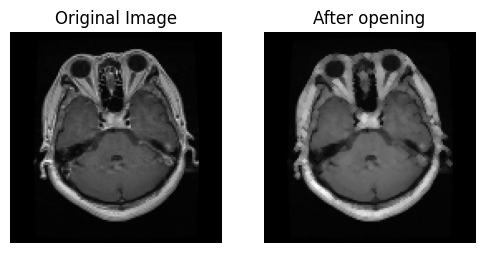

In [23]:
image = images[6]
opening_result = morphological_opening(image)
fig, axes = plt.subplots(1, 2, figsize=(6, 6))

axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')


axes[1].imshow(opening_result, cmap='gray')
axes[1].set_title("After opening")
axes[1].axis('off')

plt.show()

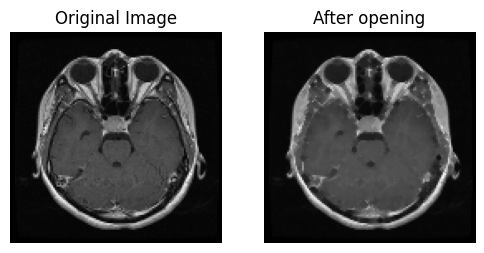

In [24]:
image = images[4]
closing_result = morphological_closing(image)
fig, axes = plt.subplots(1, 2, figsize=(6, 6))
axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(closing_result, cmap='gray')
axes[1].set_title("After opening")
axes[1].axis('off')

plt.show()

In [25]:
images.shape

(3064, 128, 128, 1)

In [26]:
masks.shape

(3064, 128, 128, 1)

# **Modelling**

# **U-net**

In [27]:
def conv_block(input_tensor, num_filters):
    x = Conv2D(num_filters, 3, padding="same")(input_tensor)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Conv2D(num_filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x

def encoder_block(input_tensor, num_filters):
    x = conv_block(input_tensor, num_filters)
    p = MaxPool2D((2, 2))(x)
    return x, p

def decoder_block(input_tensor, skip_features, num_filters):
    x = Conv2DTranspose(num_filters, 2, strides=2, padding="same")(input_tensor)
    x = Concatenate()([x, skip_features])
    x = conv_block(x, num_filters)
    return x

def unet(input_shape):
    inputs = Input(input_shape)

    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    b1 = conv_block(p4, 1024)

    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    outputs = Conv2D(1, 1, padding="same", activation="sigmoid")(d4)

    model = Model(inputs, outputs, name="UNET")
    return model


model = unet((128,128,1))
model.summary()

I0000 00:00:1765928202.497204      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "UNET"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,054,145 (118.46 MB)

 Trainable params: 31,042,369 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [28]:
def dice_score(y_true, y_pred):
     inter = np.sum(y_true * y_pred)
     return (2.0 * inter) / (np.sum(y_true) + np.sum(y_pred) + 1e-7)

def iou_score(y_true, y_pred):
     inter = np.sum(y_true * y_pred)
     union = np.sum(y_true) + np.sum(y_pred) - inter
     return inter / (union + 1e-7)

def accuracy_score(y_true, y_pred):
     return np.mean(y_true == y_pred)


def psnr(img1, img2):
    return tf.image.psnr(img1, img2, max_val=1.0).numpy()

def ssim(img1, img2):
     return tf.image.ssim(img1, img2, max_val=1.0).numpy()

def dice_coef_tf(y_true, y_pred, smooth=1e-7):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    inter = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)

    return (2. * inter + smooth) / (union + smooth)

def iou_tf(y_true, y_pred, smooth=1e-7):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    inter = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - inter

    return (inter + smooth) / (union + smooth)


In [29]:
def dice_loss(y_true, y_pred):
    return 1 - dice_coef_tf(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)


In [30]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coef_tf, iou_tf]
)

In [31]:
X = images
Y = masks
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "unet_best.h5",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
]


In [32]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100


I0000 00:00:1765928216.015902     142 service.cc:148] XLA service 0x7c6e7c045d40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765928216.016484     142 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1765928217.672169     142 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/154 ━━━━━━━━━━━━━━━━━━━━ 1:14:58 29s/step - dice_coef_tf: 0.0278 - iou_tf: 0.0141 - loss: 1.6488

I0000 00:00:1765928234.204803     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - dice_coef_tf: 0.0787 - iou_tf: 0.0419 - loss: 1.2458

...

154/154 ━━━━━━━━━━━━━━━━━━━━ 20s 132ms/step - dice_coef_tf: 0.9234 - iou_tf: 0.8582 - loss: 0.0862 - val_dice_coef_tf: 0.8137 - val_iou_tf: 0.6896 - val_loss: 0.2181
Epoch 23/100
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - dice_coef_tf: 0.9264 - iou_tf: 0.8632 - loss: 0.0826
Epoch 23: val_loss did not improve from 0.21809
154/154 ━━━━━━━━━━━━━━━━━━━━ 19s 124ms/step - dice_coef_tf: 0.9264 - iou_tf: 0.8632 - loss: 0.0826 - val_dice_coef_tf: 0.8053 - val_iou_tf: 0.6784 - val_loss: 0.2295
Epoch 24/100
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - dice_coef_tf: 0.9308 - iou_tf: 0.8709 - loss: 0.0778
Epoch 24: val_loss improved from 0.21809 to 0.21690, saving model to unet_best.h5


154/154 ━━━━━━━━━━━━━━━━━━━━ 20s 131ms/step - dice_coef_tf: 0.9308 - iou_tf: 0.8709 - loss: 0.0778 - val_dice_coef_tf: 0.8164 - val_iou_tf: 0.6931 - val_loss: 0.2169
Epoch 25/100
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - dice_coef_tf: 0.9345 - iou_tf: 0.8774 - loss: 0.0734
Epoch 25: val_loss did not improve from 0.21690
154/154 ━━━━━━━━━━━━━━━━━━━━ 19s 124ms/step - dice_coef_tf: 0.9346 - iou_tf: 0.8775 - loss: 0.0734 - val_dice_coef_tf: 0.8057 - val_iou_tf: 0.6784 - val_loss: 0.2304
Epoch 26/100
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - dice_coef_tf: 0.9436 - iou_tf: 0.8935 - loss: 0.0632
Epoch 26: val_loss improved from 0.21690 to 0.21344, saving model to unet_best.h5


154/154 ━━━━━━━━━━━━━━━━━━━━ 20s 132ms/step - dice_coef_tf: 0.9436 - iou_tf: 0.8934 - loss: 0.0633 - val_dice_coef_tf: 0.8211 - val_iou_tf: 0.7001 - val_loss: 0.2134
Epoch 27/100
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - dice_coef_tf: 0.9436 - iou_tf: 0.8936 - loss: 0.0635
Epoch 27: val_loss did not improve from 0.21344
154/154 ━━━━━━━━━━━━━━━━━━━━ 19s 125ms/step - dice_coef_tf: 0.9436 - iou_tf: 0.8936 - loss: 0.0634 - val_dice_coef_tf: 0.8090 - val_iou_tf: 0.6831 - val_loss: 0.2279
Epoch 28/100
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - dice_coef_tf: 0.9499 - iou_tf: 0.9048 - loss: 0.0565
Epoch 28: val_loss did not improve from 0.21344
154/154 ━━━━━━━━━━━━━━━━━━━━ 19s 124ms/step - dice_coef_tf: 0.9499 - iou_tf: 0.9048 - loss: 0.0565 - val_dice_coef_tf: 0.8185 - val_iou_tf: 0.6962 - val_loss: 0.2191
Epoch 29/100
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - dice_coef_tf: 0.9521 - iou_tf: 0.9089 - loss: 0.0539
Epoch 29: val_loss did not improve from 0.21344
154/154 ━━━━━━━━━━━━━━━━━

154/154 ━━━━━━━━━━━━━━━━━━━━ 20s 132ms/step - dice_coef_tf: 0.9551 - iou_tf: 0.9142 - loss: 0.0506 - val_dice_coef_tf: 0.8265 - val_iou_tf: 0.7074 - val_loss: 0.2104
Epoch 32/100
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - dice_coef_tf: 0.9463 - iou_tf: 0.8992 - loss: 0.0609
Epoch 32: val_loss did not improve from 0.21037
154/154 ━━━━━━━━━━━━━━━━━━━━ 19s 124ms/step - dice_coef_tf: 0.9460 - iou_tf: 0.8987 - loss: 0.0613 - val_dice_coef_tf: 0.7718 - val_iou_tf: 0.6318 - val_loss: 0.2796
Epoch 33/100
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - dice_coef_tf: 0.8848 - iou_tf: 0.7958 - loss: 0.1317
Epoch 33: val_loss did not improve from 0.21037
154/154 ━━━━━━━━━━━━━━━━━━━━ 19s 124ms/step - dice_coef_tf: 0.8849 - iou_tf: 0.7960 - loss: 0.1315 - val_dice_coef_tf: 0.7708 - val_iou_tf: 0.6305 - val_loss: 0.2719
Epoch 34/100
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - dice_coef_tf: 0.9229 - iou_tf: 0.8574 - loss: 0.0873
Epoch 34: val_loss did not improve from 0.21037
154/154 ━━━━━━━━━━━━━━━━━

154/154 ━━━━━━━━━━━━━━━━━━━━ 20s 131ms/step - dice_coef_tf: 0.9646 - iou_tf: 0.9318 - loss: 0.0397 - val_dice_coef_tf: 0.8278 - val_iou_tf: 0.7091 - val_loss: 0.2100
Epoch 38/100
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - dice_coef_tf: 0.9658 - iou_tf: 0.9339 - loss: 0.0386
Epoch 38: val_loss did not improve from 0.21005
154/154 ━━━━━━━━━━━━━━━━━━━━ 19s 124ms/step - dice_coef_tf: 0.9658 - iou_tf: 0.9340 - loss: 0.0386 - val_dice_coef_tf: 0.8237 - val_iou_tf: 0.7036 - val_loss: 0.2172
Epoch 39/100
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - dice_coef_tf: 0.9684 - iou_tf: 0.9388 - loss: 0.0358
Epoch 39: val_loss did not improve from 0.21005
154/154 ━━━━━━━━━━━━━━━━━━━━ 19s 124ms/step - dice_coef_tf: 0.9684 - iou_tf: 0.9389 - loss: 0.0358 - val_dice_coef_tf: 0.8230 - val_iou_tf: 0.7025 - val_loss: 0.2177
Epoch 40/100
153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - dice_coef_tf: 0.9702 - iou_tf: 0.9422 - loss: 0.0337
Epoch 40: val_loss did not improve from 0.21005
154/154 ━━━━━━━━━━━━━━━━━

In [33]:
preds = model.predict(X_val)
preds_bin = (preds > 0.5).astype(np.float32)

dice_list, iou_list, acc_list = [], [], []

for i in range(len(Y_val)):
    dice_list.append(dice_score(Y_val[i], preds_bin[i]))
    iou_list.append(iou_score(Y_val[i], preds_bin[i]))
    acc_list.append(accuracy_score(Y_val[i], preds_bin[i]))

print("Mean Dice :", np.mean(dice_list))
print("Mean IoU  :", np.mean(iou_list))
print("Mean Acc  :", np.mean(acc_list))


20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step
Mean Dice : 0.7949208521501401
Mean IoU  : 0.710147649001194
Mean Acc  : 0.9944821430847267


In [34]:
psnr_vals, ssim_vals = [], []

for i in range(len(Y_val)):
    psnr_vals.append(psnr(Y_val[i], preds[i]))
    ssim_vals.append(ssim(Y_val[i], preds[i]))

print("Mean PSNR :", np.mean(psnr_vals))
print("Mean SSIM :", np.mean(ssim_vals))


Mean PSNR : 25.699486
Mean SSIM : 0.9738618


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


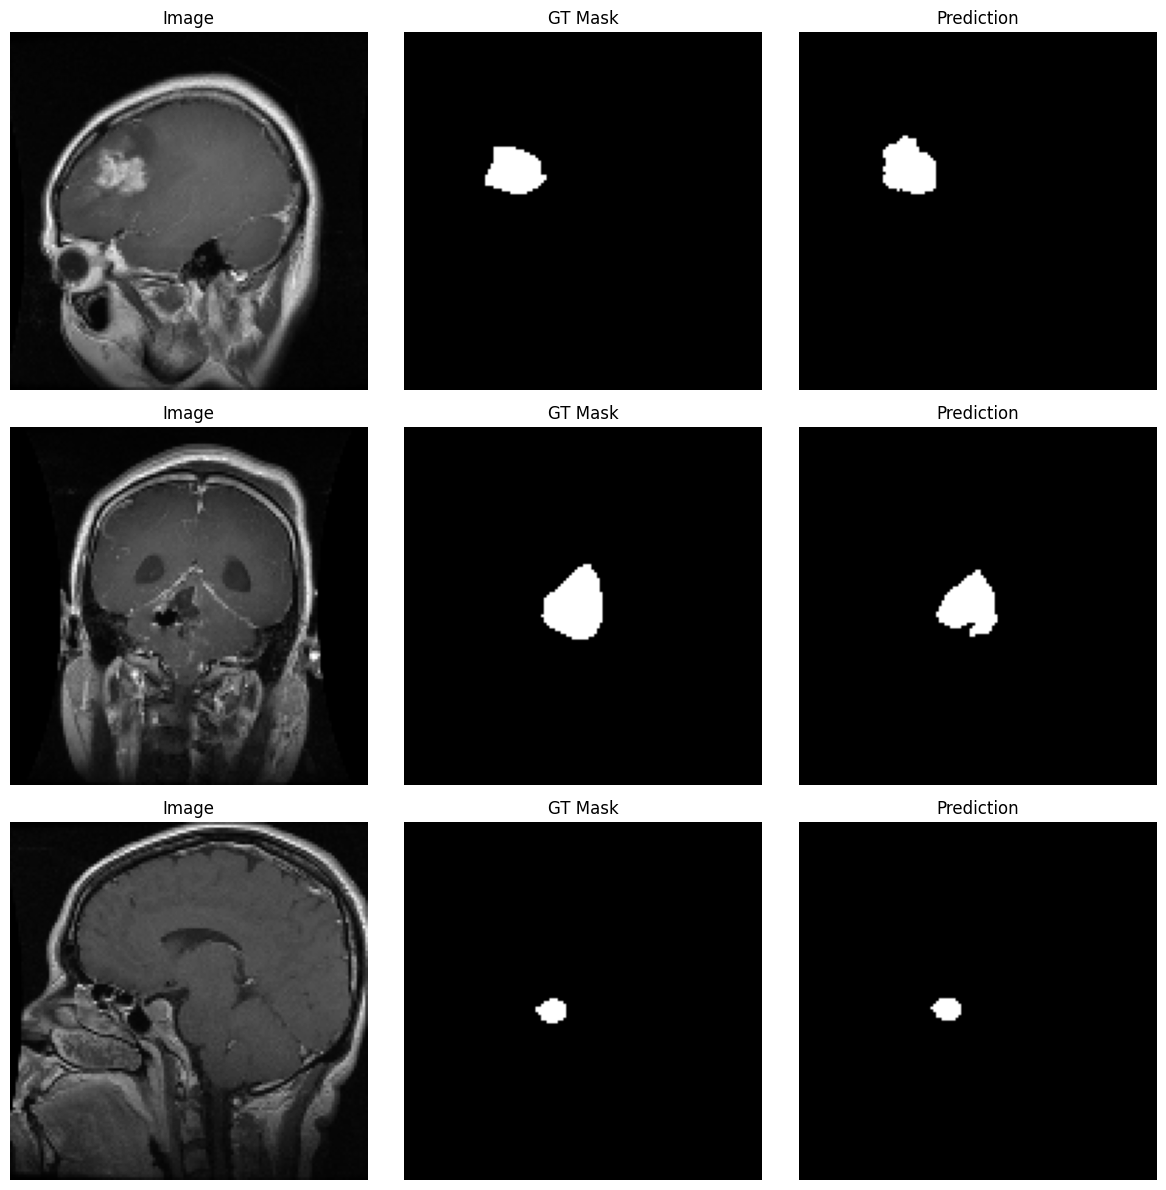

In [41]:
def show_multiple_results(images, masks, model, n=3):
    plt.figure(figsize=(12,4*n))

    for i in range(n):
        idx = np.random.randint(0, len(images))

        image = images[idx]
        true_mask = masks[idx]
        pred_mask = model.predict(image[np.newaxis, ...])[0]
        pred_mask = (pred_mask > 0.5).astype(np.float32)

        plt.subplot(n, 3, i*3 + 1)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title("Image")
        plt.axis('off')

        plt.subplot(n, 3, i*3 + 2)
        plt.imshow(true_mask.squeeze(), cmap='gray')
        plt.title("GT Mask")
        plt.axis('off')

        plt.subplot(n, 3, i*3 + 3)
        plt.imshow(pred_mask.squeeze(), cmap='gray')
        plt.title("Prediction")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

show_multiple_results(X_val, Y_val, model)

In [36]:
print(history.history.keys())

dict_keys(['dice_coef_tf', 'iou_tf', 'loss', 'val_dice_coef_tf', 'val_iou_tf', 'val_loss'])


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


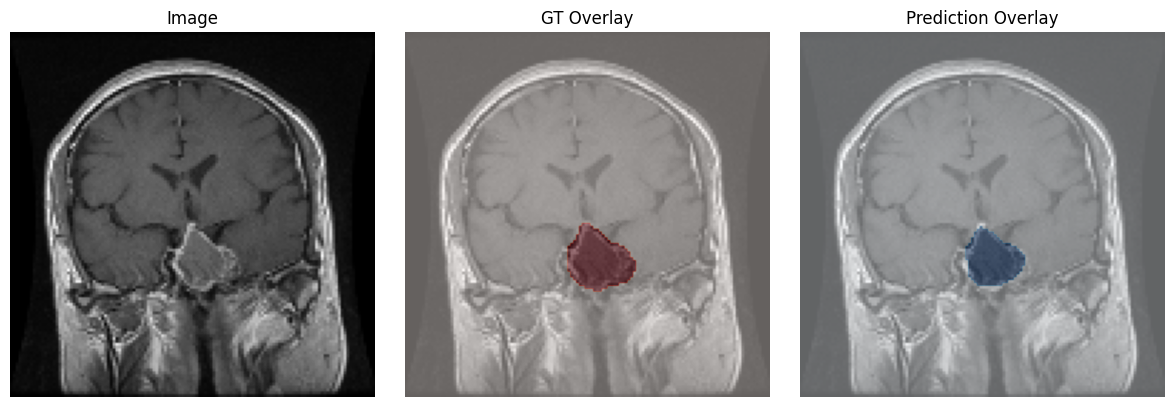

In [40]:
def show_overlay(images, masks, model, idx=None):
    if idx is None:
        idx = np.random.randint(0, len(images))

    image = images[idx].squeeze()
    true_mask = masks[idx].squeeze()
    pred_mask = model.predict(images[idx:idx+1])[0].squeeze()

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(image, cmap='gray')
    plt.title("Image")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(image, cmap='gray')
    plt.imshow(true_mask, cmap='Reds', alpha=0.4)
    plt.title("GT Overlay")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(image, cmap='gray')
    plt.imshow(pred_mask > 0.5, cmap='Blues', alpha=0.4)
    plt.title("Prediction Overlay")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

show_overlay(X_val, Y_val, model)

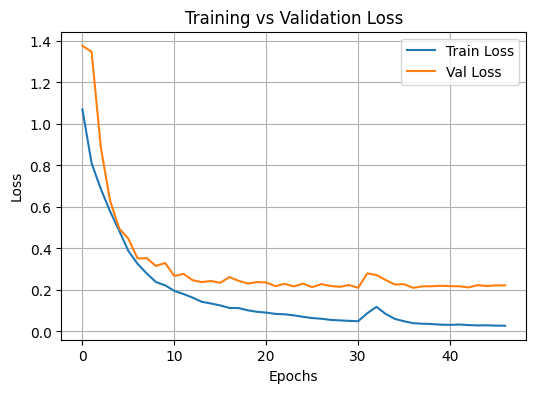

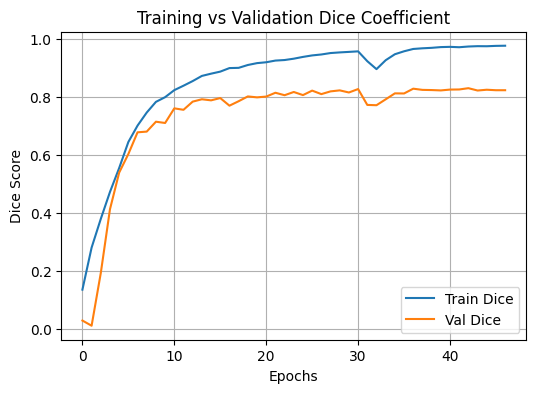

In [38]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history['dice_coef_tf'], label='Train Dice')
plt.plot(history.history['val_dice_coef_tf'], label='Val Dice')
plt.title("Training vs Validation Dice Coefficient")
plt.xlabel("Epochs")
plt.ylabel("Dice Score")
plt.legend()
plt.grid(True)
plt.show()

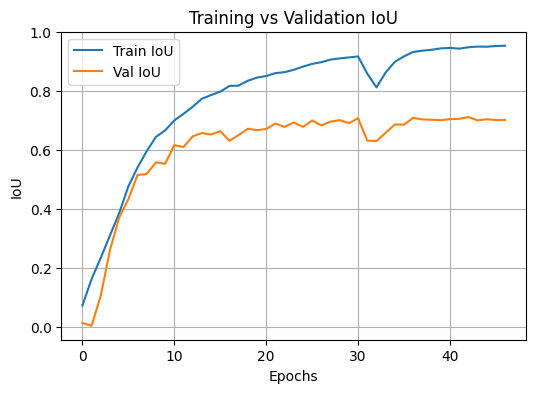

In [39]:
plt.figure(figsize=(6,4))
plt.plot(history.history['iou_tf'], label='Train IoU')
plt.plot(history.history['val_iou_tf'], label='Val IoU')
plt.title("Training vs Validation IoU")
plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.legend()
plt.grid(True)
plt.show()